In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm
import cv2
import os

In [2]:
BASE_DIR=r"DataSets/StyleGan2"

In [3]:
VALID_EXT = (".jpg", ".jpeg", ".png")
def load_data():
    data = []

    for label in ["real", "fake"]:
        folder = os.path.join(BASE_DIR, label)
        for img in os.listdir(folder):
            if img.lower().endswith(VALID_EXT):
                data.append({
                    "path": os.path.join(folder, img),
                    "label": label
                })

    return pd.DataFrame(data)

In [4]:
df = load_data()

In [5]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

In [6]:
print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nLabel distribution:")
print("Train\n", train_df["label"].value_counts())
print("Val\n", val_df["label"].value_counts())
print("Test\n", test_df["label"].value_counts())

Train: (9023, 2)
Val  : (1933, 2)
Test : (1934, 2)

Label distribution:
Train
 label
fake    4900
real    4123
Name: count, dtype: int64
Val
 label
fake    1050
real     883
Name: count, dtype: int64
Test
 label
fake    1050
real     884
Name: count, dtype: int64


In [7]:
print(train_df.head())
print(train_df["label"].value_counts())

                                            path label
3600  DataSets/StyleGan2\real\real_219_aug_0.jpg  real
9543  DataSets/StyleGan2\fake\fake_128_aug_3.jpg  fake
3199  DataSets/StyleGan2\real\real_146_aug_4.jpg  real
7910      DataSets/StyleGan2\fake\1XOP1ZW1OL.jpg  fake
8544      DataSets/StyleGan2\fake\2NONGFBQGE.jpg  fake
label
fake    4900
real    4123
Name: count, dtype: int64


In [8]:
print(test_df.head())
print(test_df["label"].value_counts())

                                             path label
9526   DataSets/StyleGan2\fake\fake_125_aug_1.jpg  fake
5655    DataSets/StyleGan2\real\real_58_aug_0.jpg  real
208             DataSets/StyleGan2\real\00300.jpg  real
1618            DataSets/StyleGan2\real\02242.jpg  real
10386  DataSets/StyleGan2\fake\fake_280_aug_1.jpg  fake
label
fake    1050
real     884
Name: count, dtype: int64


In [9]:
print(val_df.head())
print(val_df["label"].value_counts())

                                            path label
3999  DataSets/StyleGan2\real\real_290_aug_4.jpg  real
7917      DataSets/StyleGan2\fake\1XXNM7F534.jpg  fake
8983      DataSets/StyleGan2\fake\2YW3S907MZ.jpg  fake
997            DataSets/StyleGan2\real\01379.jpg  real
1016           DataSets/StyleGan2\real\01404.jpg  real
label
fake    1050
real     883
Name: count, dtype: int64


In [10]:
def resolution_eda(df, name, plot_sample=4000):

    widths  = np.empty(len(df), dtype=np.int32)
    heights = np.empty(len(df), dtype=np.int32)

    bad = 0

    for i, path in enumerate(tqdm(df["path"], desc=f"{name} scan")):
        try:
            with Image.open(path) as img:
                w, h = img.size
        except:
            w, h = -1, -1
            bad += 1

        widths[i]  = w
        heights[i] = h

    df = df.copy()
    df["width"]  = widths
    df["height"] = heights

    df = df[df["width"] > 0]

    print(f"\n{name} corrupted images:", bad)

    print(f"\n{name} resolution statistics:")
    print(df[["width", "height"]].describe())

    if len(df) > plot_sample:
        plot_df = df.sample(plot_sample, random_state=42)
    else:
        plot_df = df

    plt.figure(figsize=(6,5))
    plt.scatter(
        plot_df["width"],
        plot_df["height"],
        s=4,
        alpha=0.3
    )
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.title(f"{name} Resolution Distribution")
    plt.show()

    return df


Train scan: 100%|██████████| 9023/9023 [02:10<00:00, 69.22it/s]



Train corrupted images: 0

Train resolution statistics:
             width       height
count  9023.000000  9023.000000
mean    270.621079   270.621079
std      25.751622    25.751622
min     196.000000   196.000000
25%     256.000000   256.000000
50%     256.000000   256.000000
75%     292.000000   292.000000
max     360.000000   360.000000


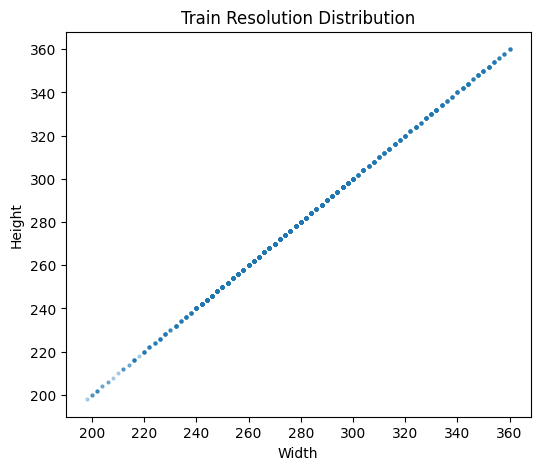

Validation scan: 100%|██████████| 1933/1933 [00:26<00:00, 71.97it/s]


Validation corrupted images: 0

Validation resolution statistics:
             width       height
count  1933.000000  1933.000000
mean    270.493533   270.493533
std      25.928365    25.928365
min     196.000000   196.000000
25%     256.000000   256.000000
50%     256.000000   256.000000
75%     290.000000   290.000000
max     360.000000   360.000000


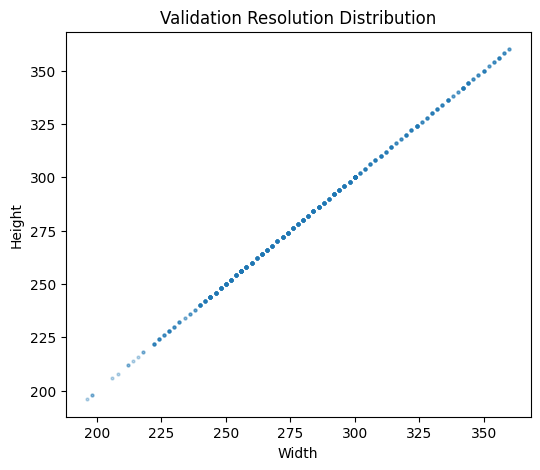

Test scan: 100%|██████████| 1934/1934 [00:26<00:00, 73.20it/s]



Test corrupted images: 0

Test resolution statistics:
             width       height
count  1934.000000  1934.000000
mean    270.709411   270.709411
std      25.927220    25.927220
min     198.000000   198.000000
25%     256.000000   256.000000
50%     256.000000   256.000000
75%     290.000000   290.000000
max     360.000000   360.000000


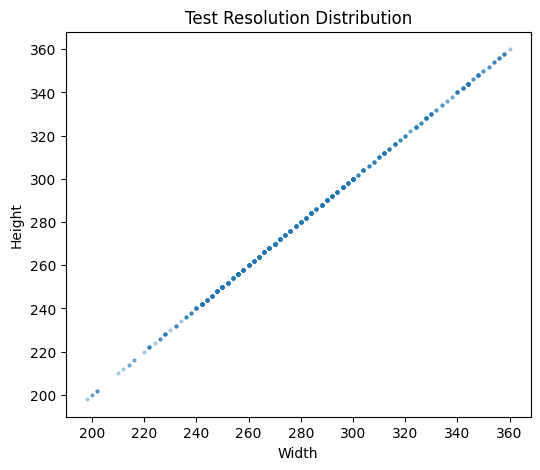

In [11]:
train_res = resolution_eda(train_df, "Train")
val_res   = resolution_eda(val_df, "Validation")
test_res  = resolution_eda(test_df, "Test")

In [12]:
def aspect_ratio_eda(res_df, name):

    res_df["aspect_ratio"] = res_df["width"] / res_df["height"]

    sns.histplot(res_df["aspect_ratio"], bins=50)
    plt.title(f"{name} Aspect Ratio Distribution")
    plt.show()

    print(res_df["aspect_ratio"].describe())

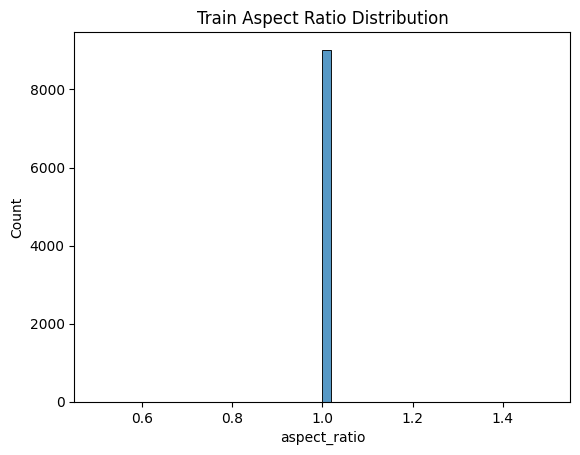

count    9023.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: aspect_ratio, dtype: float64


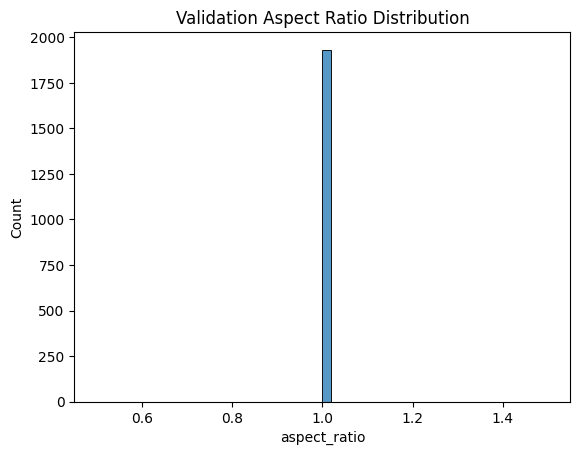

count    1933.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: aspect_ratio, dtype: float64


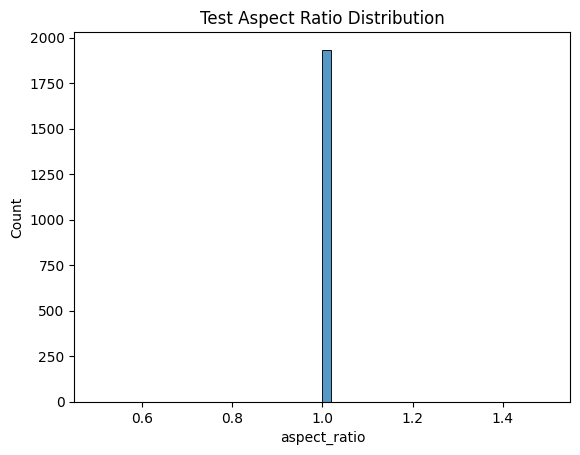

count    1934.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: aspect_ratio, dtype: float64


In [13]:
aspect_ratio_eda(train_res, "Train")
aspect_ratio_eda(val_res, "Validation")
aspect_ratio_eda(test_res, "Test")

In [14]:
def brightness_contrast_eda(df, name, sample=4000):

    sample_size = min(sample, len(df))
    temp = df.sample(sample_size, random_state=42)

    brightness = []
    contrast   = []

    for path in tqdm(temp["path"], desc=f"{name} brightness"):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue  # skip broken images

        brightness.append(img.mean())
        contrast.append(img.std())

    temp = temp.iloc[:len(brightness)].copy()
    temp["brightness"] = brightness
    temp["contrast"]   = contrast

    sns.kdeplot(data=temp, x="brightness", hue="label", fill=True)
    plt.title(f"{name} Brightness Distribution")
    plt.show()

    sns.kdeplot(data=temp, x="contrast", hue="label", fill=True)
    plt.title(f"{name} Contrast Distribution")
    plt.show()

Train brightness: 100%|██████████| 4000/4000 [00:02<00:00, 1754.74it/s]


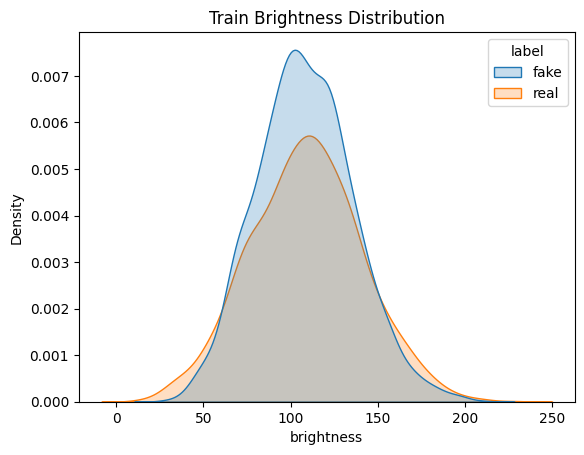

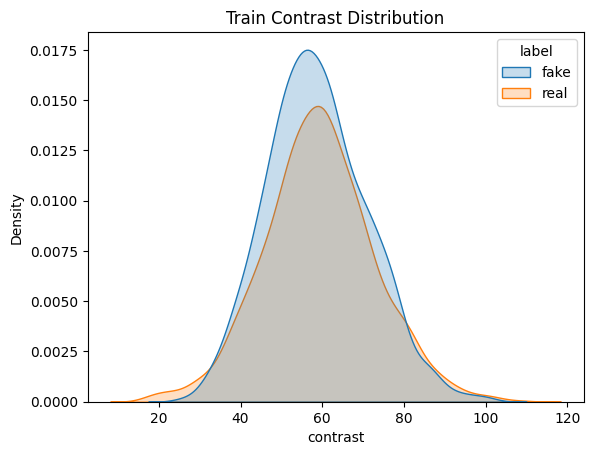

Validation brightness: 100%|██████████| 1933/1933 [00:01<00:00, 1788.84it/s]


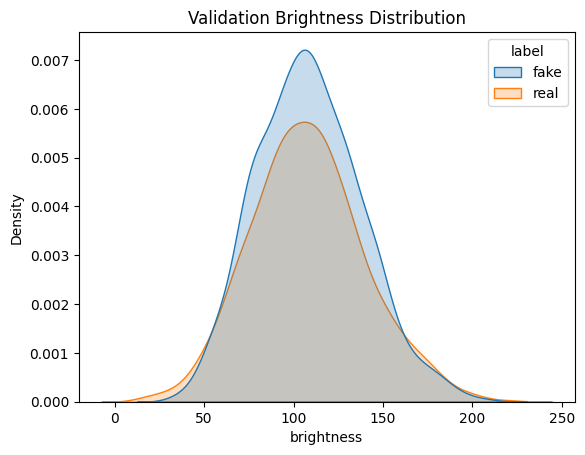

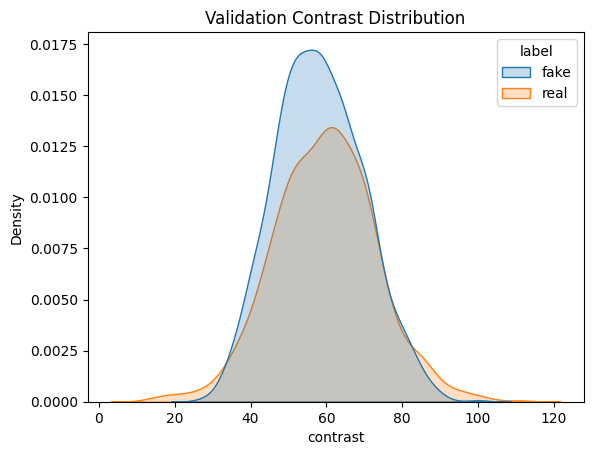

Test brightness: 100%|██████████| 1934/1934 [00:01<00:00, 1619.23it/s]


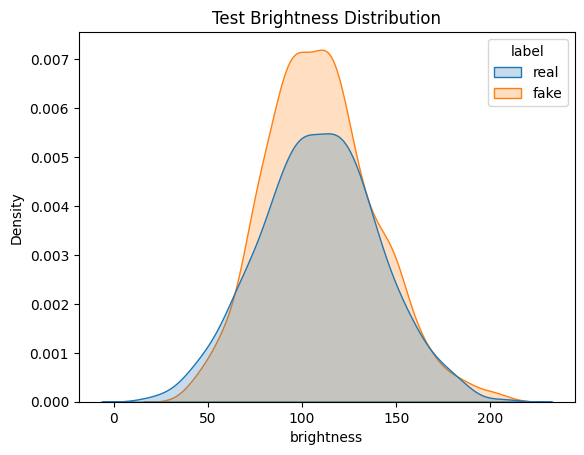

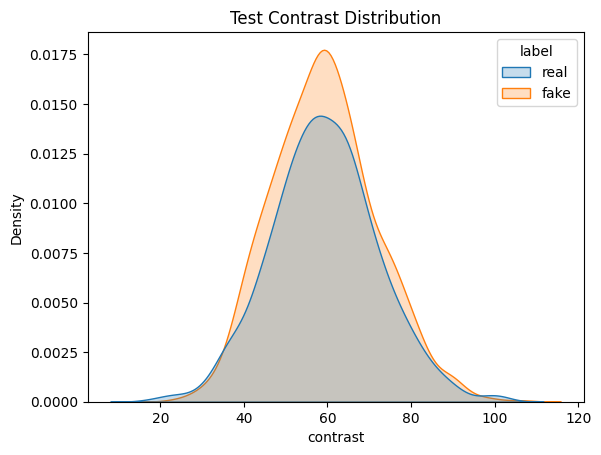

In [15]:
brightness_contrast_eda(train_df, "Train")
brightness_contrast_eda(val_df, "Validation")
brightness_contrast_eda(test_df, "Test")

In [16]:
def rgb_channel_eda(df, name):

    R, G, B = [], [], []

    for path in tqdm(df["path"], desc=f"{name} RGB"):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        r, g, b = img.mean(axis=(0,1))
        R.append(r); G.append(g); B.append(b)

    plt.figure(figsize=(8,5))
    sns.kdeplot(R, label="R")
    sns.kdeplot(G, label="G")
    sns.kdeplot(B, label="B")
    plt.title(f"{name} RGB Channel Means")
    plt.legend()
    plt.show()

Train RGB: 100%|██████████| 9023/9023 [00:11<00:00, 809.23it/s]


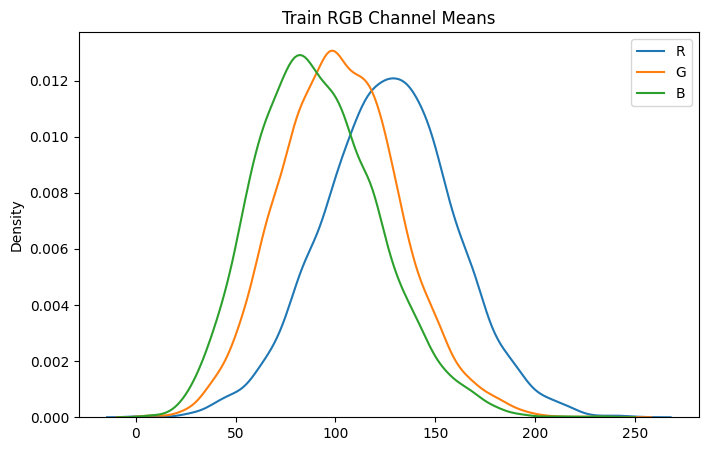

Validate RGB: 100%|██████████| 1933/1933 [00:02<00:00, 810.41it/s]


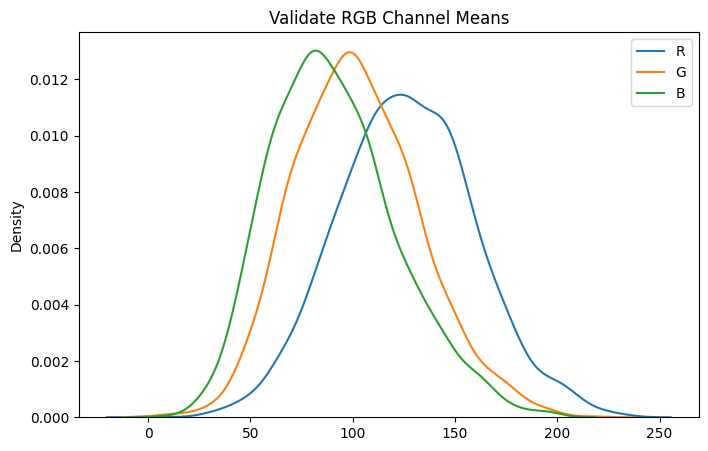

Test RGB: 100%|██████████| 1934/1934 [00:02<00:00, 804.51it/s]


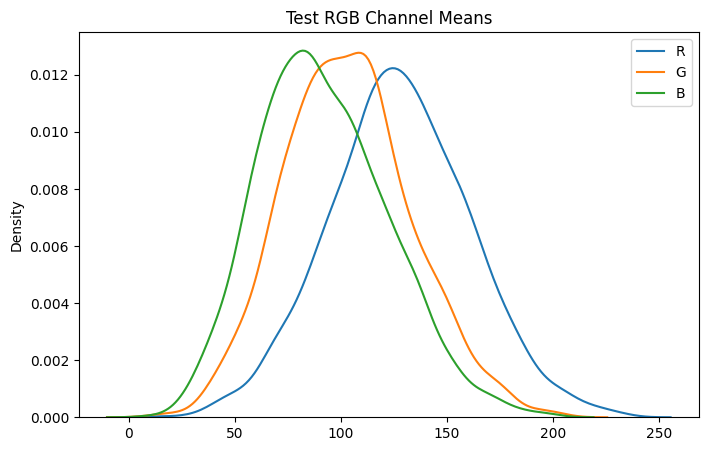

In [17]:
rgb_channel_eda(train_df,"Train")
rgb_channel_eda(val_df,"Validate")
rgb_channel_eda(test_df,"Test")

In [18]:
def fft_energy_eda(df, name, sample=2000):

    n = min(sample, len(df))
    temp = df.sample(n=n, random_state=42)

    def fft_energy(path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (256,256))
        f = np.fft.fftshift(np.fft.fft2(img))
        return np.log(np.abs(f) + 1).mean()

    temp = temp.copy()  # avoid SettingWithCopy warnings
    temp["fft_energy"] = [
        fft_energy(p) for p in tqdm(temp["path"], desc=f"{name} FFT")
    ]

    sns.kdeplot(
        data=temp,
        x="fft_energy",
        hue="label",
        fill=True
    )
    plt.title(f"{name} FFT Energy Distribution")
    plt.show()

Train FFT: 100%|██████████| 2000/2000 [00:06<00:00, 333.04it/s]


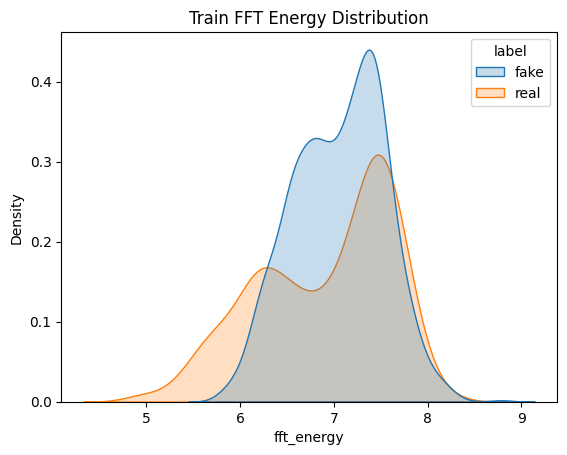

Validate FFT: 100%|██████████| 1933/1933 [00:06<00:00, 281.17it/s]


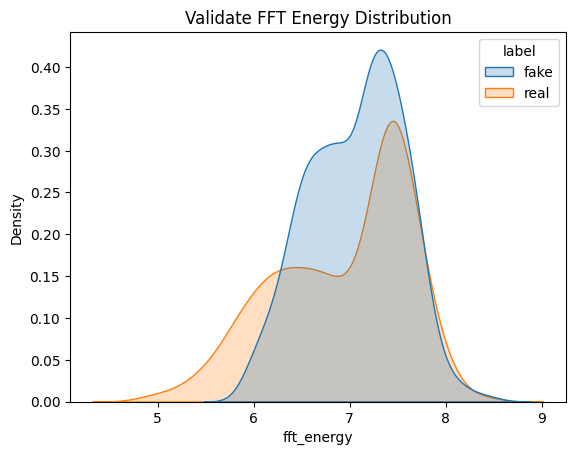

Test FFT: 100%|██████████| 1934/1934 [00:06<00:00, 300.55it/s]


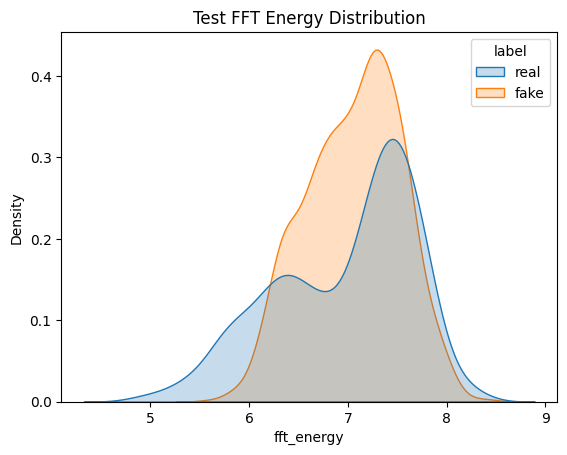

In [19]:
fft_energy_eda(train_df,"Train")
fft_energy_eda(val_df,"Validate")
fft_energy_eda(test_df,"Test")

In [20]:
def haar_face_presence_eda(df, name, sample=3000):

    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )
    assert not face_cascade.empty(), "Haar cascade failed to load"

    sample_size = min(sample, len(df))
    temp = df.sample(sample_size, random_state=42)

    faces = []

    for path in tqdm(temp["path"], desc=f"{name} Haar face check"):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            faces.append(0)
            continue

        detections = face_cascade.detectMultiScale(
            img,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(40, 40)
        )

        faces.append(1 if len(detections) > 0 else 0)

    temp = temp.copy()
    temp["face"] = faces

    print(f"\n{name} face presence rate:")
    print(temp.groupby("label")["face"].mean())

In [21]:
haar_face_presence_eda(train_df, "Train")
haar_face_presence_eda(val_df, "Validation")
haar_face_presence_eda(test_df, "Test")

Train Haar face check: 100%|██████████| 3000/3000 [00:12<00:00, 231.04it/s]



Train face presence rate:
label
fake    0.761905
real    0.585683
Name: face, dtype: float64


Validation Haar face check: 100%|██████████| 1933/1933 [00:08<00:00, 220.11it/s]



Validation face presence rate:
label
fake    0.788571
real    0.585504
Name: face, dtype: float64


Test Haar face check: 100%|██████████| 1934/1934 [00:08<00:00, 221.03it/s]


Test face presence rate:
label
fake    0.767619
real    0.618778
Name: face, dtype: float64


In [22]:
import os
import cv2
import numpy as np
import random
from tqdm import tqdm
from sklearn.model_selection import train_test_split

In [24]:
INPUT_DIR  = r"D:\SEM-6\DL\DEEP-FAKE\DataSets\StyleGan2"
OUTPUT_DIR = r"D:\SEM-6\DL\DEEP-FAKE\DataSets\StyleGan2_aligned"

IMG_SIZE = 256
VALID_EXT = (".jpg", ".jpeg", ".png")

In [25]:
def kaggle_style_crop(img, crop_ratio=0.9):
    h, w = img.shape[:2]
    ch, cw = int(h * crop_ratio), int(w * crop_ratio)

    y1 = (h - ch) // 2
    x1 = (w - cw) // 2

    return img[y1:y1+ch, x1:x1+cw]

In [26]:
def resize_256(img):
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)

In [27]:
def frequency_regularize(img):

    # reduce GAN high-frequency dominance
    if random.random() < 0.6:
        q = random.randint(70, 95)
        encode = [int(cv2.IMWRITE_JPEG_QUALITY), q]
        _, enc = cv2.imencode(".jpg", img, encode)
        img = cv2.imdecode(enc, cv2.IMREAD_COLOR)

    if random.random() < 0.4:
        img = cv2.GaussianBlur(img, (3,3), 0)

    return img

In [28]:
def color_jitter(img):
    img = img.astype(np.float32)

    c = random.uniform(0.95, 1.05)
    img = (img - 128) * c + 128

    b = random.uniform(-10, 10)
    img += b

    return np.clip(img, 0, 255).astype(np.uint8)

In [29]:
def preprocess_kaggle_style(path, train=True):

    img = cv2.imread(path)
    if img is None:
        return None

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # align framing
    img = kaggle_style_crop(img)

    # enforce resolution
    img = resize_256(img)

    if train:
        img = frequency_regularize(img)
        img = color_jitter(img)

    return img

In [30]:
def collect_paths(base_dir):
    paths, labels = [], []

    for label in ["real", "fake"]:
        folder = os.path.join(base_dir, label)
        for f in os.listdir(folder):
            if f.lower().endswith(VALID_EXT):
                paths.append(os.path.join(folder, f))
                labels.append(label)

    return paths, labels

In [31]:
paths, labels = collect_paths(INPUT_DIR)

train_p, temp_p, train_l, temp_l = train_test_split(
    paths, labels, test_size=0.30, stratify=labels, random_state=42
)

val_p, test_p, val_l, test_l = train_test_split(
    temp_p, temp_l, test_size=0.50, stratify=temp_l, random_state=42
)

In [32]:
def save_split(paths, labels, split, train=True):

    for p, lbl in tqdm(zip(paths, labels), total=len(paths), desc=f"Saving {split}"):

        img = preprocess_kaggle_style(p, train=train)
        if img is None:
            continue

        out_dir = os.path.join(OUTPUT_DIR, split, lbl)
        os.makedirs(out_dir, exist_ok=True)

        out_path = os.path.join(out_dir, os.path.basename(p))
        cv2.imwrite(out_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

In [33]:
save_split(train_p, train_l, "train", train=True)
save_split(val_p,   val_l,   "val",   train=False)
save_split(test_p,  test_l,  "test",  train=False)

Saving test: 100%|██████████| 1934/1934 [00:31<00:00, 60.48it/s]
